# Model Selection

*Which model family should we train?* This notebook compares three candidates — a Dummy baseline, LogReg, and LightGBM — runs a statistical test on whether LightGBM's edge over LogReg is real, and checks whether the current features are enough or the model is leaving signal on the table.

The model family this notebook decides is **frozen** — a human-reviewed constant (`COMMITTED_MODEL_FAMILY`), not recomputed on every retrain. Re-run this notebook only on a real trigger (a new candidate, a drift signal, a scheduled review); if the decision changes, update that constant via a reviewed PR, per `ANALYSIS.md` §4a.

**Selection criterion: PR-AUC (average precision)** throughout — the sole metric driving the decision. It's far more sensitive than ROC-AUC to ranking quality on the minority class, which matters given churn's ~27% prevalence. ROC-AUC is reported as a diagnostic only.

In [1]:
%matplotlib inline

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import HTML, Image, display
from lightgbm import LGBMClassifier
from scipy.stats import chi2
from sklearn.model_selection import RepeatedStratifiedKFold, learning_curve

load_dotenv()

import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

from telco_churn.features.build import FEATURE_SCHEMA
from telco_churn.features.preprocessing import build_preprocessor
from telco_churn.models.diagnostics import generalization_gap, learning_curve_points, segment_oof_errors
from telco_churn.models.train import run_candidate_step, run_comparison_step
from telco_churn.models.train.candidates import _FAMILY_REVIEW_CV_FOLDS, _FAMILY_REVIEW_CV_REPEATS
from telco_churn.models.train.common import (
    COMMITTED_MODEL_FAMILY,
    COMMITTED_MODEL_FAMILY_DECISION_RUN_ID,
    _load_dev_features,
    lgbm_default_params,
)
from telco_churn.utils.logging import configure_logging
from telco_churn.utils.paths import compose_config, get_project_root

configure_logging()
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1. Run the family comparison (on-demand review)

`run_candidate_step` (`models/train/candidates.py`) and `run_comparison_step` (`models/train/comparison.py`) do the work below, logging every result to the shared `telco-churn-training` experiment.

In [2]:
cfg = compose_config()

tracking_uri = str(cfg.mlflow.tracking_uri)
if "://" not in tracking_uri:
    tracking_uri = str(get_project_root() / tracking_uri)
mlflow.set_tracking_uri(tracking_uri)

X_dev, y_dev = _load_dev_features()
print(f"Dev partition: {len(y_dev)} rows, churn rate {y_dev.mean():.4f}")

candidate_results = run_candidate_step(X_dev, y_dev, cfg)
comparison = run_comparison_step(X_dev, y_dev, candidate_results, cfg)

client = mlflow.tracking.MlflowClient()

run_ids = {name: result["run_id"] for name, result in candidate_results.items()}
run_ids["model_comparison"] = comparison["run_id"]

# Compared on decision, not run_id — every execution mints a fresh run, so a run_id
# check would flag "changed" on every routine re-run. COMMITTED_MODEL_FAMILY == "N/A"
# is the pre-decision bootstrap value, handled separately so a first run reads as
# "establishing the decision," not a false "changed."
decision_run_id = run_ids["model_comparison"]
today_family = "lightgbm" if comparison["decision"] == "lgbm" else comparison["decision"]

if COMMITTED_MODEL_FAMILY == "N/A":
    print(
        f"\nNo frozen decision exists yet (COMMITTED_MODEL_FAMILY is 'N/A') — this run "
        f"establishes it. Set COMMITTED_MODEL_FAMILY={today_family!r} and "
        f"COMMITTED_MODEL_FAMILY_DECISION_RUN_ID={decision_run_id!r} in "
        "models/train/common.py, and record the rationale in ANALYSIS.md §4a, via a reviewed PR."
    )
elif today_family == COMMITTED_MODEL_FAMILY:
    print(
        f"\nReconfirmed {COMMITTED_MODEL_FAMILY!r} — no change needed. Frozen provenance still "
        f"cites COMMITTED_MODEL_FAMILY_DECISION_RUN_ID={COMMITTED_MODEL_FAMILY_DECISION_RUN_ID}; "
        f"today's run ({decision_run_id}) is fresh confirming evidence only."
    )
else:
    print(
        f"\nDECISION CHANGED: today says {today_family!r}, committed says "
        f"{COMMITTED_MODEL_FAMILY!r} (run {COMMITTED_MODEL_FAMILY_DECISION_RUN_ID}).\n"
        f"Update COMMITTED_MODEL_FAMILY/COMMITTED_MODEL_FAMILY_DECISION_RUN_ID to today's run "
        f"({decision_run_id}) in models/train/common.py, and ANALYSIS.md §4a, via a reviewed PR."
    )

Dev partition: 5634 rows, churn rate 0.2654


2026/08/08 13:10:08 INFO mlflow.tracking.fluent: Experiment with name 'telco-churn-training' does not exist. Creating a new experiment.


2026-08-08 12:10:10 UTC [info     ] candidate_cv_start             [telco_churn.models.train.candidates] candidate=dummy_prior
2026-08-08 12:10:24 UTC [info     ] candidate_cv_done              [telco_churn.models.train.candidates] candidate=dummy_prior pr_auc_mean=0.265 pr_auc_std=0.001 run_id=39aee74f89a34fe9bb3ebf524287dda6
🏃 View run dummy_prior at: http://localhost:5000/#/experiments/1/runs/39aee74f89a34fe9bb3ebf524287dda6
🧪 View experiment at: http://localhost:5000/#/experiments/1
2026-08-08 12:10:25 UTC [info     ] candidate_cv_start             [telco_churn.models.train.candidates] candidate=logreg_cv
2026-08-08 12:12:47 UTC [info     ] candidate_cv_done              [telco_churn.models.train.candidates] candidate=logreg_cv pr_auc_mean=0.651 pr_auc_std=0.033 run_id=5c80c2f580354473bd1b435276bf0d47
🏃 View run logreg_cv at: http://localhost:5000/#/experiments/1/runs/5c80c2f580354473bd1b435276bf0d47
🧪 View experiment at: http://localhost:5000/#/experiments/1
2026-08-08 12:12:47 UT

## 2. Candidate Comparison

All three candidates share one cross-validation schedule — `RepeatedStratifiedKFold(10x10)` (100 folds total), identical fold indices across candidates so the comparison is paired by construction. `dummy_prior` is trained with no access to customer features at all, so it can only guess at the overall churn rate — if it scored meaningfully better than that, something in the pipeline would be leaking information it shouldn't. `train.py` checks this automatically (ROC-AUC $\approx$ 0.5, PR-AUC $\approx$ prevalence) and aborts the run immediately if it fails, so this notebook could never end up showing a comparison built on a broken pipeline.

In [3]:
comp_dir = mlflow.artifacts.download_artifacts(run_id=run_ids["model_comparison"], artifact_path="comparison")
comparison_table = pd.read_csv(f"{comp_dir}/comparison_table.csv").set_index("candidate")
display(comparison_table)

prevalence = float(comparison_table.loc["dummy_prior", "cv_pr_auc_mean"])

,cv_pr_auc_mean,cv_pr_auc_std,pr_auc_oof,roc_auc,train_time_s,predict_time_s
candidate,,,,,,
dummy_prior,0.265,0.001,NaN,NaN,0.00,0.001
logreg_cv,0.651,0.033,0.647,0.844,1.22,0.042
lgbm_default,0.658,0.035,0.659,0.844,0.28,0.038


LightGBM and LogReg both clear the Dummy floor (PR-AUC $\approx$ prevalence, 0.265) by a wide margin — LogReg at 0.651, LightGBM at 0.658. LightGBM also trains about 4.4x faster than LogReg's inner-CV `C` search (0.28s vs. 1.22s) and edges ahead on PR-AUC by about 0.007 — whether that edge is real is exactly what the paired bootstrap in the next section answers. ROC-AUC tells a different story here: it's identical to 3dp for both candidates (0.844 vs. 0.844) despite that real PR-AUC gap — concrete evidence of the class-imbalance effect described above, since ROC-AUC is far less sensitive than PR-AUC to ranking differences at this ~27% prevalence. That's exactly why it's reported here as a diagnostic only, not the selection metric.

### PR-AUC distribution across folds

Per-fold PR-AUC was logged as the step-indexed metric `cv_pr_auc_fold` on each candidate's run (100 points per candidate — one per RSKF fold). LogReg and LightGBM share the exact same 100 folds (paired by construction), so each fold's pair of scores is connected directly below — line color marks whichever model scored higher on that fold.

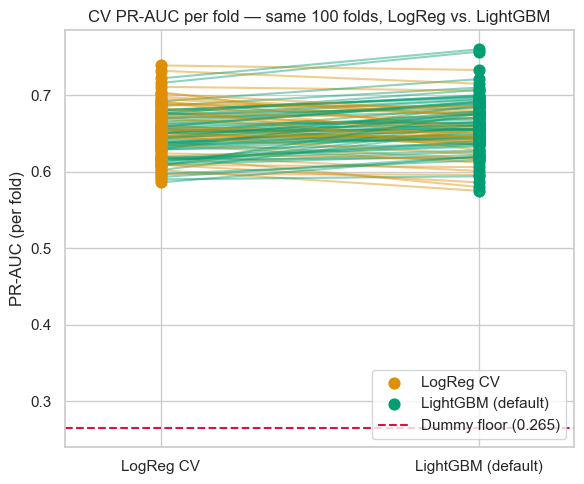

Folds                        : 100
LogReg CV range              : [0.586, 0.739]  (spread 0.153)
LightGBM range                : [0.575, 0.760]  (spread 0.185)
Mean gap (LightGBM - LogReg)  : +0.007
LightGBM wins                 : 60/100 folds (60%)


In [4]:
fold_rows = []
for name in ("logreg_cv", "lgbm_default"):
    history = client.get_metric_history(run_ids[name], "cv_pr_auc_fold")
    for h in sorted(history, key=lambda x: x.step):
        fold_rows.append({"candidate": name, "fold": h.step, "cv_pr_auc": h.value})
fold_df = pd.DataFrame(fold_rows)

fold_pivot = fold_df.pivot(index="fold", columns="candidate", values="cv_pr_auc")

logreg_color, lgbm_color = sns.color_palette("colorblind")[1], sns.color_palette("colorblind")[2]

fig, ax = plt.subplots(figsize=(6, 5))
for _, row in fold_pivot.iterrows():
    winner_color = lgbm_color if row["lgbm_default"] > row["logreg_cv"] else logreg_color
    ax.plot([0, 1], [row["logreg_cv"], row["lgbm_default"]], color=winner_color, alpha=0.45, lw=1.5, zorder=1)

ax.scatter([0] * len(fold_pivot), fold_pivot["logreg_cv"], color=logreg_color, s=60, zorder=2, label="LogReg CV")
ax.scatter([1] * len(fold_pivot), fold_pivot["lgbm_default"], color=lgbm_color, s=60, zorder=2, label="LightGBM (default)")
ax.axhline(prevalence, color="crimson", linestyle="--", lw=1.5, label=f"Dummy floor ({prevalence:.3f})")

ax.set_xlim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(["LogReg CV", "LightGBM (default)"])
ax.set_ylabel("PR-AUC (per fold)")
ax.set_title("CV PR-AUC per fold — same 100 folds, LogReg vs. LightGBM")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

n_folds = len(fold_pivot)
logreg_min, logreg_max = fold_pivot["logreg_cv"].min(), fold_pivot["logreg_cv"].max()
lgbm_min, lgbm_max = fold_pivot["lgbm_default"].min(), fold_pivot["lgbm_default"].max()
logreg_spread = logreg_max - logreg_min
lgbm_spread = lgbm_max - lgbm_min
mean_gap = fold_pivot["lgbm_default"].mean() - fold_pivot["logreg_cv"].mean()
lgbm_win_count = int((fold_pivot["lgbm_default"] > fold_pivot["logreg_cv"]).sum())

print(f"Folds                        : {n_folds}")
print(f"LogReg CV range              : [{logreg_min:.3f}, {logreg_max:.3f}]  (spread {logreg_spread:.3f})")
print(f"LightGBM range                : [{lgbm_min:.3f}, {lgbm_max:.3f}]  (spread {lgbm_spread:.3f})")
print(f"Mean gap (LightGBM - LogReg)  : {mean_gap:+.3f}")
print(f"LightGBM wins                 : {lgbm_win_count}/{n_folds} folds ({lgbm_win_count / n_folds:.0%})")

Both candidates clearly beat the Dummy baseline on every one of the 100 folds (LogReg 0.586-0.739, LightGBM 0.575-0.760, vs. a 0.265 floor) — in plain terms, neither model's average score above is a fluke from a few lucky folds. But the fold-to-fold spread within each candidate (~0.15-0.19) is roughly 22-26x wider than the gap between their means (+0.007), and LightGBM's 60/100 fold win rate is a lean majority, not a rout — exactly the kind of margin that's easy to misread by eye as a clear win when it could just as easily be noise. That's why the paired bootstrap in §3 is necessary rather than optional: it cancels the shared fold-to-fold swings visible here to test whether the +0.007 mean gap is real.

### Precision/F1-at-fixed-recall profile

Threshold-dependent diagnostics aren't reported at the default 0.5 cutoff — no threshold exists yet; that's a Phase 6 decision. Instead, `train.py` logs precision/F1/threshold at three fixed recall targets (0.70/0.80/0.90) on OOF predictions for every candidate, in `diagnostics/fixed_recall_profile.csv`.

In [5]:
diag_dir = mlflow.artifacts.download_artifacts(run_id=run_ids["model_comparison"], artifact_path="diagnostics")
fixed_recall_df = pd.read_csv(f"{diag_dir}/fixed_recall_profile.csv")
fixed_recall_df["recall_target"] = fixed_recall_df["recall_target"].map(lambda x: f"{x:.2f}")

precision_f1_table = (
    fixed_recall_df.pivot(index="candidate", columns="recall_target", values=["precision", "f1"])
    .style.format("{:.3f}")
    .set_caption("Precision / F1")
)
threshold_table = (
    fixed_recall_df.pivot(index="candidate", columns="recall_target", values="threshold")
    .style.format("{:.3f}")
    .set_caption("Threshold")
)

display(HTML(
    '<div style="display:flex; gap:40px; align-items:flex-start;">'
    f"<div>{precision_f1_table.to_html()}</div>"
    f"<div>{threshold_table.to_html()}</div>"
    "</div>"
))

Precision and F1 fall as the recall target rises — the standard tradeoff of a more permissive threshold catching more churners at the cost of more false positives (LightGBM precision: 0.574 → 0.517 → 0.446). The threshold column is the actual cutoff each candidate needed to hit that recall on its own OOF predictions, and it differs by model since their predicted-probability distributions aren't shaped the same way (LightGBM 0.572 → 0.453 → 0.269; LogReg 0.596 → 0.485 → 0.341) — neither is a committed decision threshold. LogReg and LightGBM track each other closely on precision/F1 at every target despite the different cutoffs, so this view doesn't separate the two candidates either. Dummy's threshold stays flat at its own prevalence (0.265), since a feature-blind prior gives every customer the identical predicted probability.

### Disaggregated robustness & fairness check (flag-only)

Aggregate PR-AUC (§2) can hide subgroup failure — a model can score well overall while badly underperforming on one slice of customers. This check re-runs PR-AUC within subgroups along two axes: **robustness** (`contract_type`/`tenure_cohort`/`internetservice` — a quiet failure here wastes retention spend on a slice the model can't rank well) and **fairness** (`gender`/`seniorcitizen`/`has_partner`/`dependents` — a quiet failure here means a protected group is systematically underserved). Each segment is judged against its own local churn-rate floor rather than one shared bar, since a low-prevalence segment naturally caps PR-AUC lower even for a good model. A paired row-level bootstrap additionally puts a 95% CI on the LightGBM-vs-LogReg gap within each segment, so a small per-segment lead doesn't get read as a real pattern when it's within noise.

This check is **flag-only**: PR-AUC alone still decides the model family — it only surfaces subgroup concerns for the analyst to note or investigate further.

#### Robustness

In [6]:
robustness_df = pd.read_csv(f"{diag_dir}/segment_robustness.csv")
fairness_df = pd.read_csv(f"{diag_dir}/segment_fairness.csv")
robustness_delta_df = pd.read_csv(f"{diag_dir}/segment_robustness_delta.csv")
fairness_delta_df = pd.read_csv(f"{diag_dir}/segment_fairness_delta.csv")

real_candidates = ["logreg_cv", "lgbm_default"]


def _side_by_side(df: pd.DataFrame, delta_df: pd.DataFrame) -> pd.DataFrame:
    df = df[df["candidate"].isin(real_candidates)]
    churn = df.drop_duplicates(["segment", "value"]).set_index(["segment", "value"])["churn_rate"]
    pr_auc = df.pivot(index=["segment", "value"], columns="candidate", values="pr_auc")[real_candidates]
    delta = delta_df.set_index(["segment", "value"])[["delta_obs", "delta_ci_lower", "delta_ci_upper"]]
    return pd.concat([churn, pr_auc, delta], axis=1)


robustness_compare = _side_by_side(robustness_df, robustness_delta_df)

print(
    "Robustness segments — churn-rate floor vs. LogReg / LightGBM PR-AUC, "
    "with a paired row-level bootstrap 95% CI on the LGBM-minus-LogReg delta:"
)
display(robustness_compare.style.format("{:.3f}"))

Robustness segments — churn-rate floor vs. LogReg / LightGBM PR-AUC, with a paired row-level bootstrap 95% CI on the LGBM-minus-LogReg delta:


Every robustness segment clears its own churn-rate floor comfortably — often 2-4x the floor value (e.g. two-year contracts: floor 0.029 vs. LogReg 0.101/LightGBM 0.070) — so both candidates genuinely rank customers well everywhere, not just on segments with an easy bar to clear.

A per-segment gap only matters if it holds up beyond this sample — the bootstrap CI on each gap is that test: an interval entirely above or below zero means the gap is real, one spanning zero means the models are statistically indistinguishable there. 4 of the 11 segments exclude zero. LightGBM has a confirmed edge on 0-12 months of tenure (+0.025, CI [0.005, 0.047]; the highest-churn segment, 47.4%) and no internet service (+0.092, CI [0.024, 0.164], the largest gap here; one of the lowest-churn segments, 7.5%) — spanning both risk tiers, not just the high-churn one. LogReg has a confirmed edge on 13-24 months (-0.036, CI [-0.066, -0.001]) and 49-65 months of tenure (-0.046, CI [-0.084, -0.001]). Every other split — including contract type, where point estimates are themselves mixed (LogReg ahead on one-year/two-year, LightGBM on month-to-month) — spans zero: not distinguishable from sampling noise.

#### Fairness

In [7]:
fairness_compare = _side_by_side(fairness_df, fairness_delta_df)

print(
    "Fairness segments — churn-rate floor vs. LogReg / LightGBM PR-AUC, "
    "with a paired row-level bootstrap 95% CI on the LGBM-minus-LogReg delta:"
)
display(fairness_compare.style.format("{:.3f}"))

Fairness segments — churn-rate floor vs. LogReg / LightGBM PR-AUC, with a paired row-level bootstrap 95% CI on the LGBM-minus-LogReg delta:


Every fairness segment clears its own churn-rate floor comfortably — often 2-3x the floor value (e.g. customers without dependents: floor 0.311 vs. LogReg 0.670/LightGBM 0.681) — so both candidates genuinely rank customers well across every demographic group, not just benefiting from an easier bar in some.

The same reasoning applies here: all 8 of 8 fairness segments produce a CI that spans zero, meaning none of the observed LightGBM-vs-LogReg gaps — across gender, senior-citizen status, partner status, or dependents — are distinguishable from sampling noise. That includes the `has_partner` split, where the point estimate alone showed a small apparent LogReg edge (-0.003 PR-AUC), but its CI ([-0.026, 0.016]) spans zero and shows it isn't real. In practice: choosing LightGBM for its other advantages doesn't cost anything in fairness across these groups, and that conclusion rests on a formal statistical test rather than a visual read of small numeric gaps. **No disparity is flagged for follow-up at this stage.**

## 3. Paired-Bootstrap Decision

The candidate comparison above showed LightGBM ahead on PR-AUC — but is that edge real, or just noise across folds? This section tests it directly: resample the 100 paired fold scores, track how the LightGBM-minus-LogReg gap moves, and check whether it reliably stays on one side of zero.

This is a **paired bootstrap on** $\Delta$ = AP(LightGBM) - AP(LogReg), not an overlapping-CI eyeball of the two marginal CIs — pairing matters because both candidates share the same 100 folds (see `bootstrap_comparison`'s docstring for why). The percentile CI on $\{\Delta_b\}$ *is* the test — no separate significance gate on top.

**Pre-registered decision rule** (materiality threshold $\Delta^*$ = 0.005 PR-AUC — a real gap can still be too small to act on):

| Branch | Condition | Plain English | Outcome |
|---|---|---|---|
| `lgbm_win` | CI excludes 0 in LGBM's favour AND $\Delta \geq \Delta^*$ | LightGBM wins clearly | Adopt LightGBM |
| `tie` | CI includes 0, or excludes 0 but $\lvert\Delta\rvert < \Delta^*$ | Can't tell them apart, or gap too small to matter | Practical tie — LightGBM adopted on non-statistical grounds (speed/simplicity — see the candidate comparison above) |
| `logreg_win` | CI excludes 0 in LogReg's favour AND $\Delta \leq -\Delta^*$ | LogReg wins clearly | Ship LogReg instead |

Delta = mean(AP_LGBM) - mean(AP_LogReg), paired over 100 shared folds
  Observed delta : +0.007000
  95% CI         : [+0.002000, +0.012000]
  p(delta <= 0)  : 0.0020  (informational only - the CI is the test)
  Delta*         : 0.0050
  Decision rule  : lgbm_win
  Decision       : LGBM
  Fold win rate  : LGBM beats LogReg on 60/100 folds (60%)


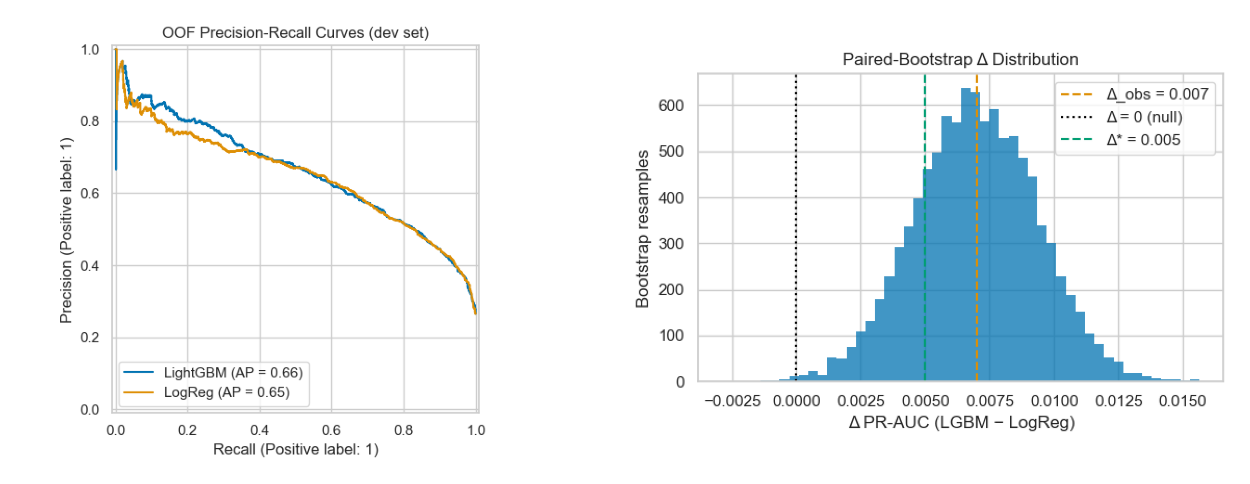

In [8]:
comp_metrics = client.get_run(run_ids["model_comparison"]).data.metrics
comp_params = client.get_run(run_ids["model_comparison"]).data.params

delta_obs = comp_metrics["bootstrap_delta_obs"]
ci_lo = comp_metrics["bootstrap_delta_ci_lower"]
ci_hi = comp_metrics["bootstrap_delta_ci_upper"]
p_value = comp_metrics["bootstrap_p_value"]
threshold = float(comp_params["delta_threshold"])
decision = comp_params["decision"]
decision_rule = comp_params["decision_rule"]

# Companion diagnostic on the same paired folds: how often LGBM's fold score beats LogReg's,
# not just the average gap. Not part of the decision rule above.
lgbm_folds = fold_df[fold_df["candidate"] == "lgbm_default"].set_index("fold")["cv_pr_auc"]
logreg_folds = fold_df[fold_df["candidate"] == "logreg_cv"].set_index("fold")["cv_pr_auc"]
lgbm_wins = int((lgbm_folds > logreg_folds).sum())
win_rate = float((lgbm_folds > logreg_folds).mean())

print("Delta = mean(AP_LGBM) - mean(AP_LogReg), paired over 100 shared folds")
print(f"  Observed delta : {delta_obs:+.6f}")
print(f"  95% CI         : [{ci_lo:+.6f}, {ci_hi:+.6f}]")
print(f"  p(delta <= 0)  : {p_value:.4f}  (informational only - the CI is the test)")
print(f"  Delta*         : {threshold:.4f}")
print(f"  Decision rule  : {decision_rule}")
print(f"  Decision       : {decision.upper()}")
print(f"  Fold win rate  : LGBM beats LogReg on {lgbm_wins}/{len(lgbm_folds)} folds ({win_rate:.0%})")

# Both logged as artifacts on the same model_comparison run (train.run_comparison_step):
# pooled-OOF precision-recall curves for the two real candidates, and the bootstrap-delta
# distribution the CI above was computed from.
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(mpimg.imread(f"{comp_dir}/pr_curves.png"))
axes[0].axis("off")
axes[1].imshow(mpimg.imread(f"{comp_dir}/bootstrap_delta_dist.png"))
axes[1].axis("off")
plt.tight_layout()
plt.show()

The CI `[+0.002, +0.012]` excludes zero entirely in LightGBM's favour, and the observed gap ($\Delta$ = 0.007) clears the materiality threshold ($\Delta^*$ = 0.005) — so `lgbm_win` fires. This is a genuine, material win for LightGBM: the paired-bootstrap decision rule adopts it on statistical grounds here, not merely on the speed/simplicity rationale from the candidate comparison above that would otherwise be needed to break a tie. That non-statistical rationale still applies and reinforces the choice, but it isn't doing the work alone in this case.

## 4. Bias/Variance and Segment-Error Diagnostic Loop

The paired-bootstrap test above settled on LightGBM as the model family. Before freezing the input feature set in `03b-feature-selection.ipynb`, this loop asks one more question: is the current 20-feature set actually sufficient, or do the errors point to something missing? It separates three explanations for imperfect PR-AUC — bias (the features can't capture the pattern → needs new features), variance (the model overfits the fit it has → needs a simpler model, whether via Optuna's regularisation search or fewer features), and localized segment failure (a specific slice underperforms → needs a targeted new feature) — so that a tuning problem doesn't get misdiagnosed as a feature gap, or vice versa.

This loop runs on development data only — the sealed test set stays untouched, preserving the test-touched-once invariant. It's also **the one place in the notebook that legitimately recomputes a model fit**: `generalization_gap` / `learning_curve_points` / `segment_oof_errors` need a live CV run's train-vs-CV scores and OOF predictions, which aren't persisted as MLflow artifacts (they exist only for the duration of `train.py`'s process).

### Bias/variance

In [9]:
binary = list(FEATURE_SCHEMA.binary)
multi_cat = list(FEATURE_SCHEMA.multi_cat)
numeric = list(FEATURE_SCHEMA.numeric)

random_state = int(cfg.random_seed)
default_params = lgbm_default_params(cfg, random_state)

cv = RepeatedStratifiedKFold(
    n_splits=_FAMILY_REVIEW_CV_FOLDS, n_repeats=_FAMILY_REVIEW_CV_REPEATS, random_state=random_state
)

train_scores, cv_scores = [], []
oof_proba = np.zeros(len(X_dev))
oof_counts = np.zeros(len(X_dev), dtype=int)

for train_idx, val_idx in cv.split(X_dev, y_dev):
    X_tr, X_val = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
    y_tr, y_val = y_dev.iloc[train_idx], y_dev.iloc[val_idx]

    preprocessor = build_preprocessor(binary, multi_cat, numeric)
    X_tr_t = preprocessor.fit_transform(X_tr)
    X_val_t = preprocessor.transform(X_val)

    model = LGBMClassifier(**default_params)
    model.fit(X_tr_t, y_tr)

    from sklearn.metrics import average_precision_score

    train_scores.append(float(average_precision_score(y_tr, model.predict_proba(X_tr_t)[:, 1])))
    val_proba = model.predict_proba(X_val_t)[:, 1]
    cv_scores.append(float(average_precision_score(y_val, val_proba)))
    oof_proba[val_idx] += val_proba
    oof_counts[val_idx] += 1

oof_proba /= oof_counts

gap = generalization_gap(train_scores, cv_scores)
print(f"Train PR-AUC (mean)       : {gap['train_pr_auc_mean']:.4f}")
print(f"CV PR-AUC (mean)          : {gap['cv_pr_auc_mean']:.4f}")
print(f"Train - CV gap (variance) : {gap['gap_mean']:.4f}")
print(f"Lift over Dummy floor     : {gap['cv_pr_auc_mean'] - prevalence:+.4f}")

Train PR-AUC (mean)       : 0.7945
CV PR-AUC (mean)          : 0.6583
Train - CV gap (variance) : 0.1362
Lift over Dummy floor     : +0.3933


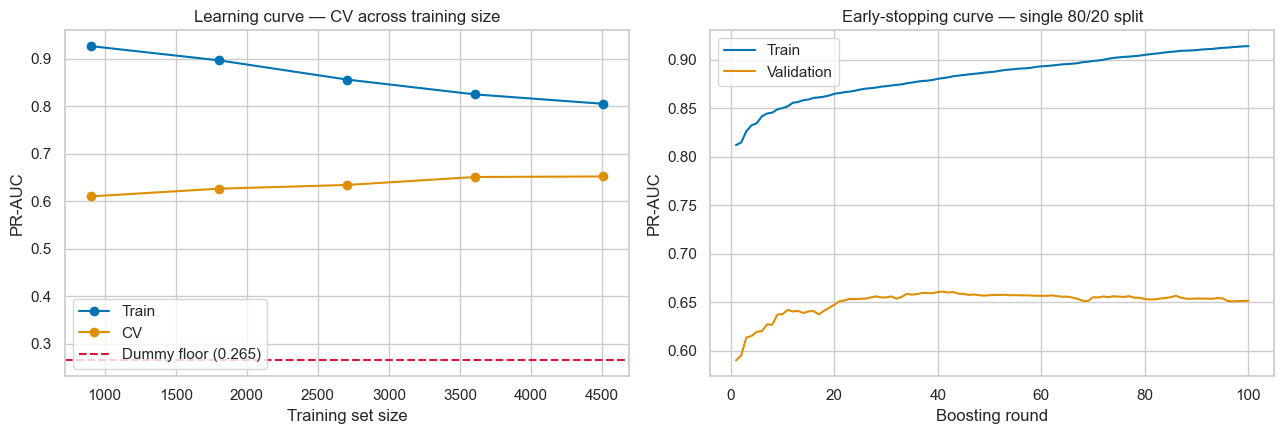

Learning curve CV PR-AUC: 0.610 (20% of dev) -> 0.652 (100% of dev)
Early-stopping best validation PR-AUC: 0.6608 at round 41/100


In [10]:
from sklearn.model_selection import train_test_split

X_tr_dev, X_val_dev, y_tr_dev, y_val_dev = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=random_state
)
preprocessor_es = build_preprocessor(binary, multi_cat, numeric)
X_tr_es = preprocessor_es.fit_transform(X_tr_dev)
X_val_es = preprocessor_es.transform(X_val_dev)

es_model = LGBMClassifier(**default_params)
es_model.fit(
    X_tr_es,
    y_tr_dev,
    eval_set=[(X_tr_es, y_tr_dev), (X_val_es, y_val_dev)],
    eval_names=["train", "val"],
    eval_metric="average_precision",
)
evals = es_model.evals_result_
rounds = np.arange(1, len(evals["train"]["average_precision"]) + 1)

train_sizes_abs, lc_train_scores, lc_cv_scores = learning_curve(
    LGBMClassifier(**default_params),
    build_preprocessor(binary, multi_cat, numeric).fit_transform(X_dev),
    y_dev,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=random_state),
    scoring="average_precision",
    n_jobs=1,
)
lc_points = learning_curve_points(train_sizes_abs.tolist(), lc_train_scores.tolist(), lc_cv_scores.tolist())
lc_df = pd.DataFrame(lc_points)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(lc_df["train_size"], lc_df["train_pr_auc_mean"], marker="o", label="Train")
axes[0].plot(lc_df["train_size"], lc_df["cv_pr_auc_mean"], marker="o", label="CV")
axes[0].axhline(prevalence, color="crimson", linestyle="--", lw=1.5, label=f"Dummy floor ({prevalence:.3f})")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Learning curve — CV across training size")
axes[0].legend()

axes[1].plot(rounds, evals["train"]["average_precision"], label="Train")
axes[1].plot(rounds, evals["val"]["average_precision"], label="Validation")
axes[1].set_xlabel("Boosting round")
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Early-stopping curve — single 80/20 split")
axes[1].legend()

plt.tight_layout()
plt.show()

best_round = int(np.argmax(evals["val"]["average_precision"])) + 1
best_val_pr_auc = max(evals["val"]["average_precision"])
print(f"Learning curve CV PR-AUC: {lc_df['cv_pr_auc_mean'].iloc[0]:.3f} (20% of dev) -> {lc_df['cv_pr_auc_mean'].iloc[-1]:.3f} (100% of dev)")
print(f"Early-stopping best validation PR-AUC: {best_val_pr_auc:.4f} at round {best_round}/{len(rounds)}")

Bias is ruled out, leaving the wide train-CV gap (well above the ~0.05 healthy guideline) as a **variance** signal — pointing to regularisation or fewer features, not new features. Three signals support this: training PR-AUC (0.7945) is already far above the Dummy floor, so the model fits the pattern; the held-out lift (+0.3933) confirms that it survives on unseen data; and the learning curve (left) shows the train-CV gap narrowing from 0.316 to 0.153 as training size grows 5x (901 → 4,507 rows) — a bias problem wouldn't shrink with more data. CV itself keeps climbing throughout (0.610 → 0.652) rather than plateauing, so more data would likely help further — a data-acquisition note, not a feature gap.

The early-stopping curve (right) makes the overfitting concrete: validation PR-AUC peaks at 0.6608 (round 41), then drifts down to 0.6513 by round 100, while train keeps climbing the whole time (0.812 → 0.914). The model keeps "improving" on data it has already memorised, well past the point where validation peaked — exactly where regularisation or fewer features should cut in. (Single 80/20 split, illustrative only — not the fold-averaged number driving the decision.)

### OOF segment profiling

In [11]:
service_flags = [
    (X_dev["phoneservice"] == "Yes").astype(int),
    (X_dev["multiplelines"] == "Yes").astype(int),
    (X_dev["internetservice"] != "No").astype(int),
    (X_dev["onlinesecurity"] == "Yes").astype(int),
    (X_dev["onlinebackup"] == "Yes").astype(int),
    (X_dev["deviceprotection"] == "Yes").astype(int),
    (X_dev["techsupport"] == "Yes").astype(int),
    (X_dev["streamingtv"] == "Yes").astype(int),
    (X_dev["streamingmovies"] == "Yes").astype(int),
]
service_count = sum(service_flags)
service_quintile = pd.qcut(service_count, 5, labels=False, duplicates="drop")

tenure_band = pd.cut(
    X_dev["tenure"], bins=[-1, 12, 36, 200], labels=["< 12m", "12-36m", "> 36m"]
).astype(str)

charge_outlier = (X_dev["charge_per_service"] > X_dev["charge_per_service"].quantile(0.95)).map(
    {True: "outlier", False: "normal"}
)

segments = {
    "contract_type": X_dev["contract_type"],
    "tenure_band": tenure_band,
    "service_quintile": pd.Series(service_quintile, name="service_quintile").astype(str),
    "charge_per_service_outlier": charge_outlier,
}

segment_rows = []
for seg_name, seg_series in segments.items():
    for row in segment_oof_errors(y_dev.tolist(), oof_proba.tolist(), seg_series.rename(seg_name)):
        segment_rows.append(row)
segment_df = pd.DataFrame(segment_rows)

# Bootstrap 95% CI on each segment's own PR-AUC, since a point estimate alone can't say
# whether a small segment's score is reliable or just noise from few positive rows.
y_dev_arr = y_dev.to_numpy()


def _segment_pr_auc_ci(mask: np.ndarray, n_boot: int = 1000, seed: int = 42) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    y_seg, p_seg = y_dev_arr[mask], oof_proba[mask]
    n = len(y_seg)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        y_b = y_seg[idx]
        if len(np.unique(y_b)) < 2:
            continue
        scores.append(average_precision_score(y_b, p_seg[idx]))
    return tuple(np.percentile(scores, [2.5, 97.5]))


ci_bounds = [
    _segment_pr_auc_ci((segments[row.segment] == row.value).to_numpy())
    for row in segment_df.itertuples()
]
segment_df["pr_auc_ci_lower"] = [lo for lo, _ in ci_bounds]
segment_df["pr_auc_ci_upper"] = [hi for _, hi in ci_bounds]

segment_df.style.format(
    {"churn_rate": "{:.3f}", "pr_auc": "{:.3f}", "pr_auc_ci_lower": "{:.3f}", "pr_auc_ci_upper": "{:.3f}"}
)

,segment,value,n,churn_rate,pr_auc,pr_auc_ci_lower,pr_auc_ci_upper
0,contract_type,Month-to-month,3095,0.428,0.694,0.667,0.721
1,contract_type,One year,1178,0.110,0.188,0.150,0.236
2,contract_type,Two year,1361,0.029,0.070,0.043,0.118
3,tenure_band,12-36m,1480,0.254,0.547,0.496,0.605
4,tenure_band,< 12m,1756,0.474,0.754,0.722,0.785
5,tenure_band,> 36m,2398,0.120,0.360,0.311,0.422
6,service_quintile,0,1666,0.190,0.644,0.595,0.694
7,service_quintile,1,687,0.438,0.726,0.673,0.778
8,service_quintile,2,1521,0.347,0.662,0.617,0.707
9,service_quintile,3,742,0.255,0.663,0.593,0.730


Every segment's PR-AUC clears its own churn-rate floor by a healthy margin, and the bootstrap 95% CI lower bound clears it too — even accounting for sampling uncertainty. The margin is narrowest on the same two segments flagged in the robustness check — one-year (floor 0.110, CI lower bound 0.150) and two-year contracts (floor 0.029, CI lower bound 0.043, ~39 churners) — small, low-churn segments where sampling noise has the most room to matter, but the lower bound still clears the floor there. Every other segment's margin is at least 3x wider. Service-count churn is non-monotonic (a genuine pattern, peaking at quintile 1) but the model tracks it without degrading. **No systematic failure pattern is identified, and the CI confirms this isn't just a point-estimate artifact of small segments.**

## Summary

This notebook runs the candidate comparison (Dummy baseline vs. LogReg vs. LightGBM), the paired-bootstrap decision test between the two real candidates, the disaggregated robustness/fairness segment check, and the bias/variance and OOF segment-error diagnostic loop that runs before the feature-selection freeze. Decision logic lives in `src/telco_churn/models/train/` (`candidates.py::run_candidate_step`, `comparison.py::run_comparison_step`) — this notebook is the only caller; the automated pipeline (`python -m telco_churn.models.train`) builds directly against `models/train/common.py::COMMITTED_MODEL_FAMILY` and never re-decides it.

The paired-bootstrap test resolves `lgbm_win`: LightGBM's PR-AUC edge over LogReg is both statistically real and large enough to act on, clean across every fairness segment, with only a small, evenly-split set of confirmed sub-segment differences in the flag-only robustness check (4 of 11 segments; 2 favouring each model, none reversing the decision), and reinforced by its speed and simplicity advantage from the candidate comparison. The diagnostic loop attributes the model's remaining error to variance, not bias, with no systematic OOF segment failure — so feature selection proceeds without adding new features.

**If this run's decision or numbers differ from `ANALYSIS.md` §4a, update `models/train/common.py::COMMITTED_MODEL_FAMILY`/`COMMITTED_MODEL_FAMILY_DECISION_RUN_ID` and `ANALYSIS.md` §4a via a reviewed PR — this notebook records evidence, it does not itself commit the decision.** Full narrative: **[§4a Model Selection](../ANALYSIS.md#4a-model-selection)** in `ANALYSIS.md`. Continue to **`03b-feature-selection.ipynb`** for the input-space freeze.